In [1]:
import os
    
import sys
import numpy as np

import torch
import zuko
    
from geobed.utils.sample_distribution import SampleDistribution
from geobed import BED_base_explicit, BED_base_nuisance

if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'

    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)

from helpers.geographic_setup import (
    design_space_full, design_space_shoulder,
    events_shoulder, events_full
)    

from helpers.helper_functions import (
    logistic_picking_likelihood_tt,
    Data_Likelihood_PL, Data_Likelihood,
    TTLookup
)

from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')


PLOT_SETUP = False
n_workers = 1  # or lower, depending on the task

In [ ]:
design_space = design_space_full

model_prior_samples = torch.load('data/priors/prior_samples_full_uniform.pt')
model_prior_sample_dist = SampleDistribution(
    model_prior_samples)

forward_function = TTLookup(
    model_prior_samples, design_space_full,
    torch.load('data/data_lookup/homogeneous_full_disp.pt'),)

data_likelihood = Data_Likelihood(
                forward_function=forward_function,
                dependence_distance=100.0,
                vel_sigma=0.05,
                tt_obs_std=0.01, 
            )

BED_class = BED_base_explicit(
    data_likelihood_func=data_likelihood,
    m_prior_dist=model_prior_sample_dist,
)

In [3]:
N_designs = 100
N_rec = 5

N_design_space = design_space.shape[0]

In [4]:
# designs = torch.stack([
#     design_space[
#         torch.randperm(len(design_space))[:N_rec]] 
#     for _ in range(N_designs)])

# eig = BED_class.calculate_EIG(
#     designs,
#     eig_method='NMC',        
#     eig_method_kwargs=dict(N = 1000, reuse_M = True),
#     # num_workers=5,
#     parallel_library='mpire',
# )[0]

# print(eig)

In [5]:
from deap import base, creator, tools
import random

creator.create("Fitness", base.Fitness, weights=(1.0,))
creator.create("Individual", set, fitness=creator.Fitness)

toolbox = base.Toolbox()
toolbox.register(
    "attribute", random.randint, 0, N_design_space-1)
toolbox.register(
    "individual", tools.initRepeat, creator.Individual,
    toolbox.attribute, n=N_rec)
toolbox.register(
    "population", tools.initRepeat, list, toolbox.individual)

In [ ]:
def eval(individual):
        
    design = design_space[list(individual)]

    BED_class.m_prior_dist._reset_sample_generator()

    eig = BED_class.calculate_EIG(
        design.unsqueeze(0),
        eig_method='NMC',        
        eig_method_kwargs=dict(N = 500, reuse_M = True),
        num_workers=n_workers,
        random_seed=0,
    )[0].item()
    
    # print(f'Individual: {individual}, EIG: {eig}')
    return (eig,)

def cxSet(ind1, ind2):
    """Crossover that preserves set properties and length."""


    
                
    return ind1, ind2
    

def mutSet(individual):
    """Mutation that randomly change one element of the set."""

    # print('mutating =============')
    # print(individual)

    if len(individual) != N_rec:
        print('ALARMMMMMM mut 1')
        print(individual)

    if random.random() < 0.5:
        individual.pop()
        
        # add new element that is not already in the individual
        new_element = random.randint(0, N_design_space-1)
        while new_element in individual:
            new_element = random.randint(0, N_design_space-1)
        individual.add(new_element)

    if len(individual) != N_rec:
        print('ALARMMMMMM mut 1')
        print(individual)

    # print(individual)
    # print('mutating =============')
    # print()

    return individual,

In [7]:
toolbox.register("evaluate", eval)
toolbox.register("mate", cxSet)
toolbox.register("mutate", mutSet)

toolbox.register("select", tools.selNSGA2)

In [11]:
from deap import algorithms

N_pop = 16

N_generations = 100

cross_prob = 0.6
mut_prob = 0.2

pop = toolbox.population(n=N_pop)
hof = tools.ParetoFront()
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean, axis=0)
stats.register("std", np.std, axis=0)
stats.register("min", np.min, axis=0)
stats.register("max", np.max, axis=0)

# there is a chance that individuals with less receivers are generated, those will be weed out after the first generation
torch.manual_seed(0)
random.seed(0)

final_pop, log = algorithms.eaSimple(
    pop, toolbox,
    cross_prob, mut_prob,
    N_generations,
    stats, halloffame=hof, verbose=True);

gen	nevals	avg         	std         	min         	max         
0  	16    	[2.66092589]	[0.14662255]	[2.29101372]	[2.83999372]
1  	4     	[2.60695428]	[0.20040713]	[2.09139228]	[2.83999372]
2  	8     	[2.61390933]	[0.19440204]	[2.09139228]	[2.82077098]
3  	5     	[2.58864605]	[0.19114154]	[2.09139228]	[2.83711481]
4  	12    	[2.62674591]	[0.24044531]	[1.85587072]	[2.88224411]
5  	14    	[2.65276732]	[0.182792]  	[2.16729641]	[2.9195857] 
6  	11    	[2.64494346]	[0.21223845]	[2.16729641]	[2.89594483]
7  	9     	[2.6455882] 	[0.16884498]	[2.39577031]	[2.92687154]
8  	13    	[2.69160838]	[0.16526718]	[2.38583994]	[2.89302921]
9  	10    	[2.73989707]	[0.1400196] 	[2.39712334]	[2.89302921]
10 	7     	[2.66196418]	[0.17629836]	[2.39712334]	[2.88834262]
11 	12    	[2.63897023]	[0.19110383]	[2.29470253]	[2.95717406]
12 	13    	[2.61458284]	[0.14064701]	[2.41369343]	[2.85028124]
13 	11    	[2.64415139]	[0.147563]  	[2.39339924]	[2.8743186] 
14 	14    	[2.74551947]	[0.1472908] 	[2.42893553]	[2.94

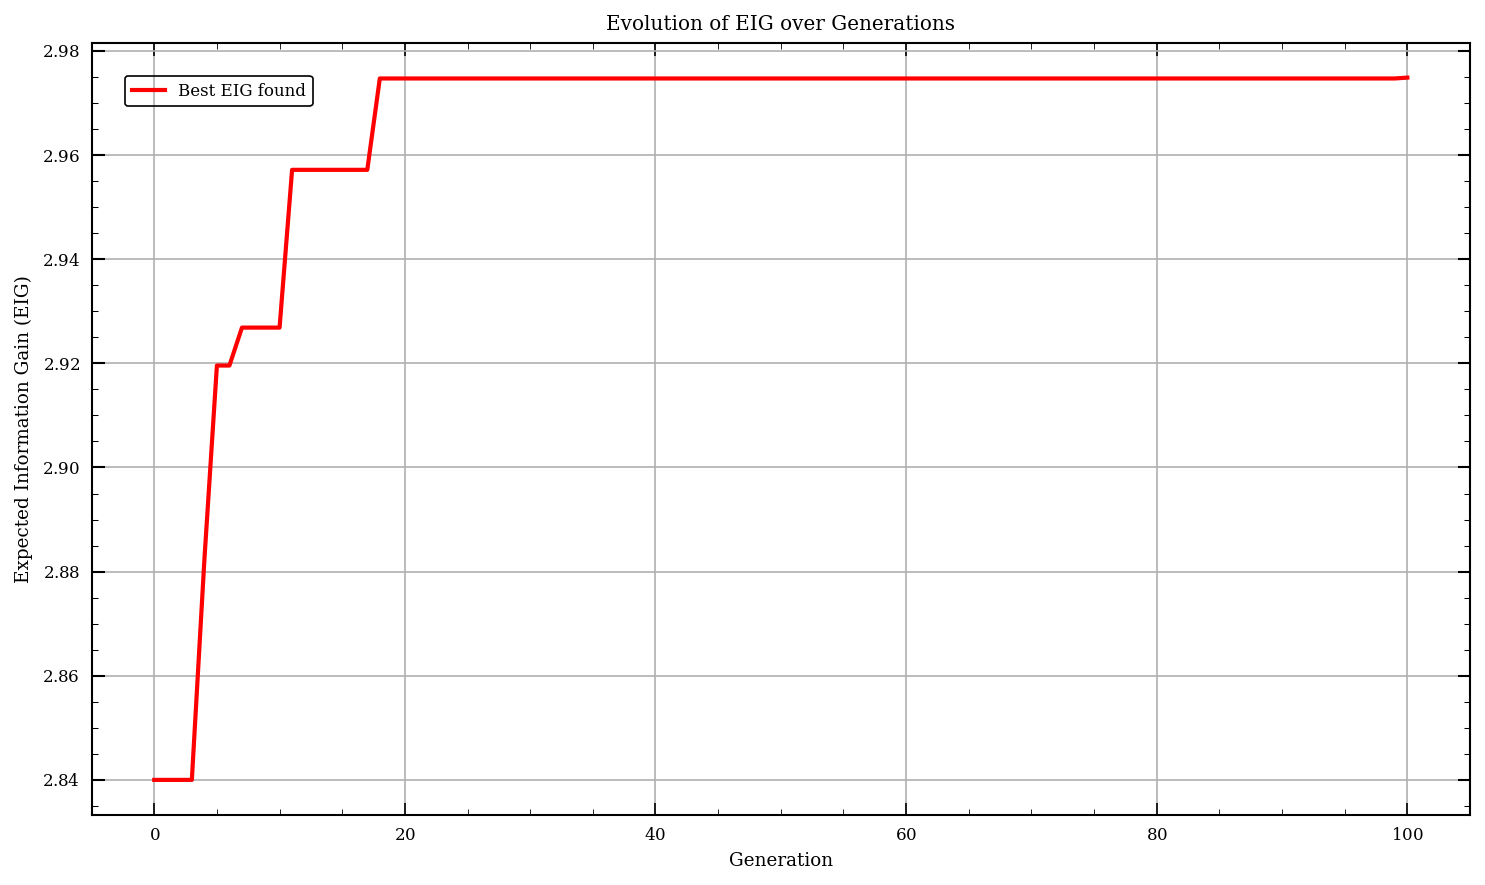

In [14]:
# Extract statistics from the logbook
gen = range(N_generations+1)
avg_eig = [_l['avg'].item() for _l in log]
min_eig = [_l['min'].item() for _l in log]
max_eig = [_l['max'].item() for _l in log]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot as a step function that only shows increasing maximum values
max_vals = []
current_max = float('-inf')
for val in max_eig:
    current_max = max(current_max, val)
    max_vals.append(current_max)
ax.plot(gen, max_vals, 'r-', label='Best EIG found', linewidth=2)

ax.set_xlabel('Generation')
ax.set_ylabel('Expected Information Gain (EIG)')
ax.set_title('Evolution of EIG over Generations')
ax.legend()
ax.grid(True)

plt.tight_layout()

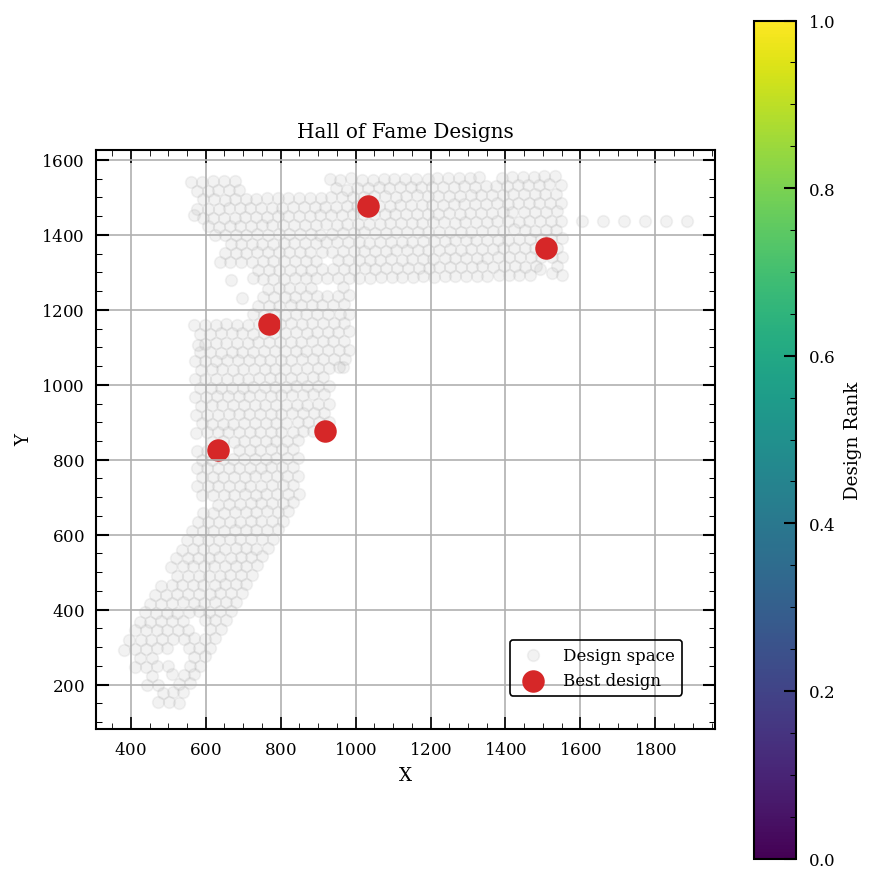

In [15]:
# Get all designs from hall of fame
fig, ax = plt.subplots(figsize=(6, 6))

# Plot full design space
ax.scatter(design_space[:, 0], design_space[:, 1], c='gray', alpha=0.1, label='Design space')

# Plot best design from hall of fame with viridis colormap
best_individual = list(hof)[0]
design = design_space[list(best_individual)]

scatter = ax.scatter(
    design[:, 0], design[:, 1],
    c='tab:red', s=100, alpha=1.0,
    label='Best design')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
ax.legend()
ax.set_title('Hall of Fame Designs')
ax.grid(True)
plt.colorbar(scatter, ax=ax, label='Design Rank')

plt.tight_layout()